# VQ-VAE on Audio (van den Oord et al., 2017 §4.2)

复现原论文音频部分：
1. 用 1D 卷积编码器 + VQ 把 16 kHz 原始波形压成离散 token 序列（约 64× 降采样）。
2. 用 **conditional WaveNet** 解码器，依赖 (token, speaker) 重建 μ-law 波形。
3. 阶段二：冻结 VQ-VAE，对 token 序列训一个 1D causal WaveNet 先验，自回归采样 → 解码 → 生成新音频。

和你之前图像版的主要差别：
- 编码器 / 解码器从 2D 卷积换成 1D；
- 解码器是自回归的 (WaveNet)，目标是 μ-law 256 类 cross-entropy；
- 先验从 2D PixelCNN 换成 1D causal WaveNet；
- 多说话人 → 引入 speaker embedding，可做 voice conversion。

# 1. 导包 + 全局变量

### 1.1 导包

In [2]:
import sys
print(sys.executable)
%load_ext autoreload
%autoreload 2

d:\anaconda3\envs\dl\python.exe


In [3]:
# ============================================================
# 标准库 & 数值
# ============================================================
import os
import random
import numpy as np

# ============================================================
# 深度学习
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# ============================================================
# 音频
# torchaudio: PyTorch 官方音频库, 提供 IO / 重采样 / mu-law / mel-spec 等
# ============================================================
import torchaudio
import torchaudio.functional as AF
import torchaudio.transforms as AT

# ============================================================
# 可视化与试听 (notebook 专用)
#   - matplotlib: 画波形
#   - IPython.display.Audio: 在 notebook 里嵌入可播放音频控件
#   - tqdm: 进度条
# ============================================================
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from tqdm import tqdm

# ============================================================
# 本仓库自有模块
# ============================================================
import GetData
import Model
import Train

# 固定随机种子, 保证 sanity check / 切分可复现
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("torch       :", torch.__version__)
print("torchaudio  :", torchaudio.__version__)
print("cuda        :", torch.cuda.is_available())
# print("audio backends:", torchaudio.list_audio_backends())

torch       : 2.11.0+cu130
torchaudio  : 2.11.0+cpu
cuda        : True


### 1.2 全局变量

音频专属超参（与论文 §4.2 对齐，结合你已有图像版的命名风格）。

In [14]:
# ============================================================
# 音频 I/O 相关
# ------------------------------------------------------------
#   SAMPLE_RATE      : 目标采样率, 论文用 16 kHz
#   SEGMENT_SAMPLES  : 训练片段长度 (单位: 采样点), 16000 ≈ 1 秒
#                      必须能被 DOWNSAMPLE_FACTOR 整除, 否则 token 长度对不齐
#   MU_LAW_CHANNELS  : μ-law 量化等级 (论文 256)
#   DOWNSAMPLE_FACTOR: Encoder 总下采样倍率 (= 2^6, 6 个 stride=2 卷积)
#   TOKEN_LEN        : 一段音频被压成 latent 后的时间步数
# ============================================================
SAMPLE_RATE       = 16000
SEGMENT_SAMPLES   = 8000
MU_LAW_CHANNELS   = 256
DOWNSAMPLE_FACTOR = 64
TOKEN_LEN         = SEGMENT_SAMPLES // DOWNSAMPLE_FACTOR   # 250

# ============================================================
# 数据集路径
# ------------------------------------------------------------
# DATA_ROOT 下的一级子目录名 = speaker_id, 子目录里可嵌套 wav/flac
#   VCTK_092 推荐路径: data/VCTK/wav48_silence_trimmed/
#   也可指向任意 "speaker / *.wav" 的自定义数据集
# ============================================================
DATA_ROOT  = r"..\data\VCTK\wav48_silence_trimmed"
BATCH_SIZE = 16

# ============================================================
# VQ-VAE 网络超参 (后续模型构建会用到)
# ============================================================
HIDDEN_CHANNELS   = 256
RESIDUAL_CHANNELS = 64
RESIDUAL_LAYERS   = 2
NUM_EMBEDDINGS    = 512        # 码本大小 K
EMBEDDING_DIM     = 64         # 码本维度 D
DECAY             = 0.99       # EMA 历史保留系数
COMMIT_COST       = 0.25       # commitment loss 系数 β

# ============================================================
# 训练超参
# ============================================================
EPOCHS     = 3
PRINT_EPOC = 1
lr         = 2e-4
wd         = 0.0
device     = "cuda:0" if torch.cuda.is_available() else "cpu"

print(f"device          = {device}")
print(f"SEGMENT_SAMPLES = {SEGMENT_SAMPLES} ({SEGMENT_SAMPLES/SAMPLE_RATE:.2f}s)")
print(f"TOKEN_LEN       = {TOKEN_LEN}")

device          = cuda:0
SEGMENT_SAMPLES = 8000 (0.50s)
TOKEN_LEN       = 125


# 2. 数据获取

目标数据集：**VCTK Corpus** (16 kHz, 109 speakers)。

Pipeline:
1. 加载 wav → 重采样到 16 kHz → 单声道 → 归一化到 `[-1, 1]`。
2. 训练时随机裁剪 `SEGMENT_SAMPLES` 个采样点 (`~1s`)。
3. μ-law 量化得到 `(B, T)` 的 long 标签，同时保留浮点波形作编码器输入。
4. 返回 `(waveform_float, waveform_mulaw, speaker_id)`。

### 2.1 μ-law 编 / 解码工具 *(补充)*

**为什么要做 μ-law？**

WaveNet 解码器不是回归连续浮点波形，而是把"下一采样点"当作 **256 类分类**：把 \([-1, 1]\) 的浮点幅度量化成 256 个桶，每一步用 cross-entropy 预测落在哪个桶里。μ-law 是一种对数式量化，**对小幅度处量化分辨率更高**（人耳对小幅度更敏感），所以听感比线性量化好得多。

公式：
$$
f(x) = \mathrm{sign}(x)\cdot \frac{\ln(1+\mu\,|x|)}{\ln(1+\mu)},\quad x\in[-1,1],\ \mu=255
$$

工具已经实现在 `GetData.py` 里（见 `mu_law_encode / mu_law_decode`），底层调用 `torchaudio.functional.mu_law_encoding / mu_law_decoding`。下面只是 import 一下方便后面调用。

In [5]:
from GetData import mu_law_encode, mu_law_decode

# 快速自测: 浮点波形 -> μ-law 量化 -> 反量化, 看误差是否在量化噪声量级
_test_float = torch.linspace(-1.0, 1.0, steps=8)        # (8,) ∈ [-1, 1]
_test_int   = mu_law_encode(_test_float, MU_LAW_CHANNELS)  # (8,) long ∈ [0, 255]
_test_rec   = mu_law_decode(_test_int,   MU_LAW_CHANNELS)  # (8,) float ≈ [-1, 1]

print("float in :", _test_float.tolist())
print("mulaw    :", _test_int.tolist())
print("decoded  :", [f"{v:.4f}" for v in _test_rec.tolist()])
print("max err  :", (_test_float - _test_rec).abs().max().item())

float in : [-1.0, -0.7142857313156128, -0.4285714030265808, -0.14285707473754883, 0.14285707473754883, 0.4285714030265808, 0.7142857313156128, 1.0]
mulaw    : [0, 8, 19, 44, 211, 236, 247, 255]
decoded  : ['-1.0000', '-0.7050', '-0.4354', '-0.1442', '0.1442', '0.4354', '0.7050', '1.0000']
max err  : 0.00929182767868042


### 2.2 音频 Dataset + DataLoader

数据处理逻辑统一放在 `src/GetData.py` 里：

- `AudioFolderDataset`：通用 "speaker / *.audio" 目录式数据集。`__getitem__` 返回:
  - `waveform_float` `(T,)` float32, 范围 `[-1, 1]` —— 喂给 Encoder
  - `waveform_mulaw` `(T,)` long, 范围 `[0, 255]` —— WaveNet 解码器 cross-entropy 的目标
  - `speaker_id` int —— 全局条件
- `get_audio_loaders(...)`：一键给出 `(train_loader, valid_loader, test_loader, speaker_map)`，按说话人内部 90/5/5 切分，保证每个 speaker 都在三个集合里出现（voice conversion 必需）。

每条样本里 `T = SEGMENT_SAMPLES`，对应一段 ~1 秒的等长片段。短的会零填充，长的会随机/固定裁剪。具体细节看 `GetData.py` 里的逐行注释。

> **数据准备提示**：如果还没下载 VCTK_092，可以先把任意"多说话人 wav 数据集"放到一个目录（每个子目录一个 speaker）当成 placeholder 跑通。VCTK_092 下载方式（任选其一）：
> - 通过 `torchaudio.datasets.VCTK_092(root='../data', download=True)` 自动下载（约 11 GB，第一次会很慢）；
> - 或手动从 https://datashare.ed.ac.uk/handle/10283/3443 下载并解压到 `data/VCTK/` 下。

In [6]:
train_loader, valid_loader, test_loader, speaker_map = GetData.get_audio_loaders(
    data_root       = DATA_ROOT,
    batch_size      = BATCH_SIZE,
    segment_samples = SEGMENT_SAMPLES,
    sample_rate     = SAMPLE_RATE,
    mu_law_channels = MU_LAW_CHANNELS,
    train_ratio     = 0.90,
    valid_ratio     = 0.05,
    seed            = SEED,
    num_workers     = 4,        # Windows 先用 0 跑通; Linux/Mac 可调到 4~8
    pin_memory      = True,
)

NUM_SPEAKERS = len(speaker_map)
# 反向映射: 整型 id -> speaker 名, 后面打印调试用
id_to_speaker = {i: name for name, i in speaker_map.items()}

print(f"speakers      : {NUM_SPEAKERS}")
print(f"train batches : {len(train_loader)}  (drop_last=True)")
print(f"valid batches : {len(valid_loader)}")
print(f"test  batches : {len(test_loader)}")
print(f"sample id_to_speaker: {dict(list(id_to_speaker.items())[:5])}")

[get_audio_loaders] 110 speakers | train 79446 | valid 4367 | test 4515
speakers      : 110
train batches : 4965  (drop_last=True)
valid batches : 273
test  batches : 283
sample id_to_speaker: {0: 'p225', 1: 'p226', 2: 'p227', 3: 'p228', 4: 'p229'}


### 2.3 数据 sanity check *(补充)*

在大规模训练之前，**一定要先听 / 看一下数据**，确认：

1. **形状对**：`waveform` 是 `(B, T=SEGMENT_SAMPLES)`，`mulaw` 同形状但 dtype 是 long，`speaker` 是 `(B,)` long。
2. **数值范围对**：浮点波形在 `[-1, 1]` 之间，没有 NaN / 全 0 / clipping (绝对值贴边过多)。
3. **听感正常**：原始波形和 μ-law decode 后的波形听起来几乎一样 (μ-law 量化只会引入轻微噪声)。
4. **speaker 覆盖正常**：训练 batch 里 speaker 分布不应该过于集中（否则说明洗牌没做好）。

下面分三步做 sanity check。

In [7]:
# ---------- (1) 取一个 batch, 打印形状 / dtype / 范围 ----------
# iter(train_loader) 拿一个迭代器, next() 取出第一个 batch
# 返回的三个张量都是 CPU 张量, 形状对齐到 (B, T) / (B, T) / (B,)
wav_f, wav_mu, spk = next(iter(train_loader))

print("waveform_float :", wav_f.shape,  wav_f.dtype,  "range=[", wav_f.min().item(),  ",", wav_f.max().item(),  "]")
print("waveform_mulaw :", wav_mu.shape, wav_mu.dtype, "range=[", wav_mu.min().item(), ",", wav_mu.max().item(), "]")
print("speaker_id     :", spk.shape,    spk.dtype,    "first 8 =", spk[:8].tolist())

# 检查异常值
assert torch.isfinite(wav_f).all(),                "waveform 出现 NaN/Inf!"
assert wav_f.abs().max() <= 1.0 + 1e-5,            "浮点波形越过 [-1, 1]!"
assert wav_mu.min() >= 0 and wav_mu.max() < MU_LAW_CHANNELS, "mu-law 标签越界!"
print("[sanity] shape / dtype / range OK")

waveform_float : torch.Size([16, 8000]) torch.float32 range=[ -0.5945481657981873 , 0.5339286923408508 ]
waveform_mulaw : torch.Size([16, 8000]) torch.int64 range=[ 12 , 241 ]
speaker_id     : torch.Size([16]) torch.int64 first 8 = [33, 88, 80, 42, 14, 96, 41, 34]
[sanity] shape / dtype / range OK


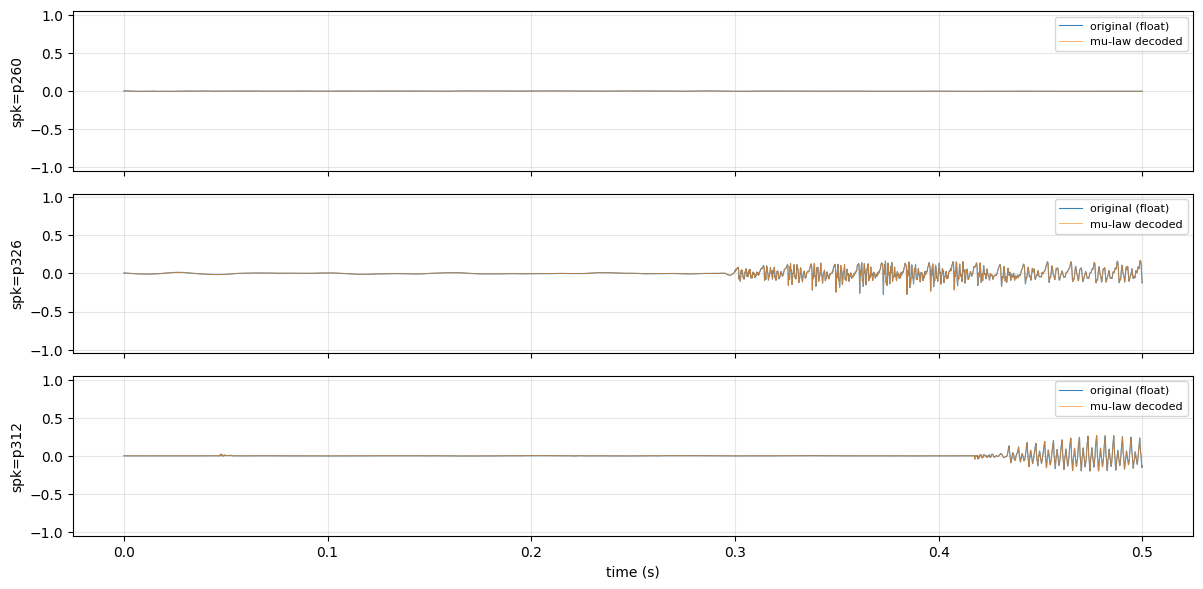

In [8]:
# ---------- (2) 画 3 条样本的波形 (原始 vs μ-law decode 后) ----------
# 把 mu-law 整型张量解回浮点, 用来和原始波形对照
wav_mu_back = mu_law_decode(wav_mu, MU_LAW_CHANNELS)   # (B, T) float, ≈ [-1, 1]

# 时间轴 (秒) = 采样点索引 / 采样率
t = np.arange(SEGMENT_SAMPLES) / SAMPLE_RATE           # (T,)

n_show = min(3, wav_f.size(0))
fig, axes = plt.subplots(n_show, 1, figsize=(12, 2.0 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]   # 只有 1 个时 axes 不是数组, 手动包一层

for i in range(n_show):
    ax = axes[i]
    ax.plot(t, wav_f[i].numpy(),       label="original (float)",     linewidth=0.8, alpha=0.9)
    ax.plot(t, wav_mu_back[i].numpy(), label="mu-law decoded",       linewidth=0.6, alpha=0.7)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel(f"spk={id_to_speaker[spk[i].item()]}")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

In [9]:
# ---------- (3) 在 notebook 里直接试听 ----------
# IPython.display.Audio(data, rate=...) 会渲染一个 HTML <audio> 控件
#   data 接受 1D numpy 数组 (单声道); float 范围最好在 [-1, 1]
#   rate 是采样率, 必须和波形一致, 否则播放会变调
# 注意: Audio(...) 必须配合 display(...) 才能在 for 循环中多次显示
for i in range(min(2, wav_f.size(0))):
    print(f"\n样本 {i}  speaker={id_to_speaker[spk[i].item()]}")
    print("  原始 float 波形:")
    display(Audio(wav_f[i].numpy(),       rate=SAMPLE_RATE))
    print("  μ-law decode 后:")
    display(Audio(wav_mu_back[i].numpy(), rate=SAMPLE_RATE))


样本 0  speaker=p260
  原始 float 波形:


  μ-law decode 后:



样本 1  speaker=p326
  原始 float 波形:


  μ-law decode 后:


speakers in train : 110
per-speaker count : min=154  max=903  mean=722.2  median=749


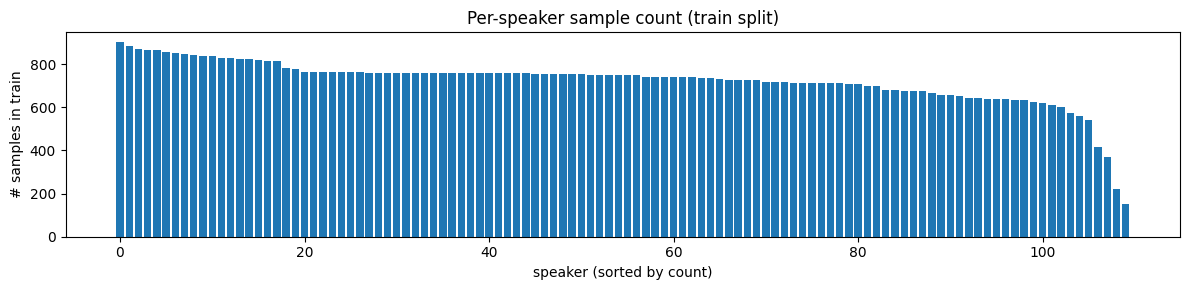

In [10]:
# ---------- (4) speaker 分布检查 ----------
# 遍历整个训练集 (只取 speaker_id, 不读音频) 看每个说话人有多少条样本
# 直接拿 dataset 而不是 loader, 避免反复触发音频解码
train_ds = train_loader.dataset
spk_count = {}
for _, spk_name in train_ds.files:
    spk_count[spk_name] = spk_count.get(spk_name, 0) + 1

counts = np.array(list(spk_count.values()))
print(f"speakers in train : {len(spk_count)}")
print(f"per-speaker count : min={counts.min()}  max={counts.max()}  "
      f"mean={counts.mean():.1f}  median={np.median(counts):.0f}")

plt.figure(figsize=(12, 3))
plt.bar(range(len(counts)), sorted(counts.tolist(), reverse=True))
plt.xlabel("speaker (sorted by count)")
plt.ylabel("# samples in train")
plt.title("Per-speaker sample count (train split)")
plt.tight_layout()
plt.show()

# 3. 模型构建

音频版的网络已全部追加到 `src/Model.py` 末尾，**`VectorQuantizerEMA` 直接复用**（通过 `unsqueeze` 把 1D 适配到原 2D 接口，不改原代码）：

- `Encoder1D`：6 层 stride=2 的 1D 卷积，把 `(B, 1, T)` 下采样 64× 成 `(B, D, T/64)`，后接 `ResidualStack1D`。
- `CausalConv1d`：因果 1D 卷积，在序列左侧 pad，输出长度仍为 T，不看未来。
- `WaveNetBlock`：dilated causal 1D conv + gated activation；同时注入**局部条件**（上采样后的 `z_q`）与**全局条件**（speaker embedding）。
- `WaveNetDecoder`：堆叠若干 `WaveNetBlock`，接 1×1 输出头得到 `(B, 256, T)` logits。
- `AudioVQVAE`：把上面三块拼起来，对外提供 `forward / encode / decode`。
- `WaveNet1DPrior`：纯 1D causal WaveNet，输入 token 序列 + speaker，输出 `(B, K, T_lat)` logits（用于阶段二先验）。

下面实例化 `AudioVQVAE` 并跑一次冒烟前向，确认形状链路对得上。

In [11]:
# ============================================================
# WaveNet decoder 专属超参 (放在这里, 避免污染 1.2 节的核心超参表)
# ------------------------------------------------------------
#   WN_RESIDUAL_CHANNELS : 每层残差路径通道 C_res
#   WN_SKIP_CHANNELS     : skip 路径通道 C_skip
#   WN_KERNEL_SIZE       : 因果卷积核宽 (论文 2)
#   WN_DILATION_CYCLES   : 几个 "1,2,4,...,2^(L-1)" 周期
#   WN_LAYERS_PER_CYCLE  : 每周期层数
#       论文典型 30 层 = 3 周期 * 10 层; 这里小机器先用 2*10 = 20 层
#   SPEAKER_DIM          : speaker embedding 维度
# ============================================================
WN_RESIDUAL_CHANNELS = 128
WN_SKIP_CHANNELS     = 256
WN_KERNEL_SIZE       = 2
WN_DILATION_CYCLES   = 2
WN_LAYERS_PER_CYCLE  = 10
SPEAKER_DIM          = 128


def build_audio_vqvae():
    """工厂方法: 后面 "搜索 ckpt + 加载" 也会复用, 保证两次实例化结构完全一致."""
    return Model.AudioVQVAE(
        # ---- 共享 ----
        num_speakers      = NUM_SPEAKERS,
        speaker_dim       = SPEAKER_DIM,
        mu_law_channels   = MU_LAW_CHANNELS,
        downsample_factor = DOWNSAMPLE_FACTOR,
        # ---- Encoder + VQ ----
        hidden_channels   = HIDDEN_CHANNELS,
        residual_channels = RESIDUAL_CHANNELS,
        residual_layers   = RESIDUAL_LAYERS,
        num_embeddings    = NUM_EMBEDDINGS,
        embedding_dim     = EMBEDDING_DIM,
        decay             = DECAY,
        commitment_cost   = COMMIT_COST,
        # ---- WaveNet decoder ----
        wn_residual_channels = WN_RESIDUAL_CHANNELS,
        wn_skip_channels     = WN_SKIP_CHANNELS,
        wn_kernel_size       = WN_KERNEL_SIZE,
        wn_dilation_cycles   = WN_DILATION_CYCLES,
        wn_layers_per_cycle  = WN_LAYERS_PER_CYCLE,
    )




In [11]:
# 临时实例化做一次冒烟前向: 形状对了再继续
_tmp_model = build_audio_vqvae().to(device)
_n_params = sum(p.numel() for p in _tmp_model.parameters())
print(f"AudioVQVAE params: {_n_params/1e6:.2f} M")

AudioVQVAE params: 4.17 M


In [12]:
with torch.no_grad():
    _wf, _mu, _spk = next(iter(train_loader))
    _wf  = _wf.to(device)
    _mu  = _mu.to(device)
    _spk = _spk.to(device)
    _commit, _perp, _logits = _tmp_model(_wf, _mu, _spk)
    print(f"forward shapes  : wf{tuple(_wf.shape)}  mu{tuple(_mu.shape)}  "
          f"spk{tuple(_spk.shape)}  ->  logits{tuple(_logits.shape)}")
    print(f"                  commit={_commit.item():.4f}  perp={_perp.item():.2f}")

    _idx = _tmp_model.encode(_wf)
    print(f"encode  : wf{tuple(_wf.shape)} -> indices{tuple(_idx.shape)}  "
          f"min={_idx.min().item()} max={_idx.max().item()}")

forward shapes  : wf(16, 8000)  mu(16, 8000)  spk(16,)  ->  logits(16, 256, 8000)
                  commit=0.1216  perp=1.00
encode  : wf(16, 8000) -> indices(16, 125)  min=159 max=159


In [13]:
del _tmp_model, _wf, _mu, _spk, _commit, _perp, _logits, _idx
if device.startswith("cuda"):
    torch.cuda.empty_cache()

# 4. 模型训练与保存

训练函数已经实现在 `src/Train.py` 里 (`train_audio` / `valid_audio` / `train_audio_pipeline`)：

- **Loss** = `F.cross_entropy(logits, mu_law_target) + commit_loss`
- **监控** = `train_total / train_recon / train_commit / train_perplexity / val_recon`
- **best 判定** = `val_recon` 最小 (而不是 train loss, 防过拟合)

整套训练流程按下面 4 个子节走：

| 子节 | 做什么 |
|---|---|
| 4.1 | 初始化模型 + **搜索 `checkpoints/best_vqvae_audio.pt` 是否已有**, 有就加载权重并拿到 `prev_best_val_recon` |
| 4.2 | 调用 `Train.train_audio_pipeline` 跑 `EPOCHS` 轮, 拿到本次训练得到的 `cur_best_model` 和 `cur_best_val_recon` |
| 4.3 | 把 `cur_best_val_recon` 与 `prev_best_val_recon` 比较, **只有更好才覆盖 checkpoint** |
| 4.4 | 画训练曲线 (total / recon / commit / val_recon / perplexity) |

### 4.1 初始化模型 + 搜索 / 加载已有最佳模型

逻辑：
1. 用 `build_audio_vqvae()` 工厂方法实例化一份新模型；
2. 检查 `CKPT_PATH` 是否存在：
   - **存在**：把权重加载到刚实例化的模型里，并把里面的 `best_val_recon` 取出来当作 `prev_best_val_recon`（后面要拿它和本轮训练得到的 best 做比较）；
   - **不存在**：`prev_best_val_recon = +inf`（任何训练结果都"更好"）。

In [12]:
SAVE_DIR  = r"..\checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
CKPT_PATH = os.path.join(SAVE_DIR, "best_vqvae_audio.pt")

# ---- (1) 新建一份模型 ----
init_model = build_audio_vqvae().to(device)

In [13]:
# ---- (2) 搜索是否已有 best ckpt ----
prev_best_val_recon = float("inf")
if os.path.isfile(CKPT_PATH):
    print(f"[ckpt] 发现已有最佳模型: {CKPT_PATH}")
    # weights_only=False 保留 config / history (老 ckpt 风格)
    _ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    # 加载权重作为本次训练的"起点", 等价于 fine-tune / continue
    init_model.load_state_dict(_ckpt["model_state_dict"])
    prev_best_val_recon = _ckpt.get("best_val_recon", float("inf"))
    print(f"        prev best val_recon = {prev_best_val_recon:.4f}")
    print(f"        将从这份权重继续训练 {EPOCHS} 个 epoch")
else:
    print(f"[ckpt] 未发现已有 ckpt, 从零开始训练")
    print(f"        prev best val_recon = +inf  (任何结果都将被保存)")

[ckpt] 发现已有最佳模型: ..\checkpoints\best_vqvae_audio.pt
        prev best val_recon = 1.0194
        将从这份权重继续训练 1 个 epoch


### 4.2 训练模型

调用 `Train.train_audio_pipeline`，它内部：
- 跑 `EPOCHS` 个 epoch，每轮做 `train_audio` + `valid_audio`；
- **本次训练**中按 `val_recon` 最小保留 `cur_best_model`（deepcopy）；
- 把已加载的 `prev_best_val_recon` 作为 `init_best_loss` 传进去——这样 pipeline 在本次训练里只有真正打破历史最好成绩的 epoch 才会触发 `cur_best_model` 更新。

返回值：
- `cur_best_model`：本次训练得到的最佳模型（**可能为 None**，如果本轮没刷新历史最佳就保持 None）；
- `cur_best_val_recon`：对应的 val_recon；
- `history`：dict，含五条曲线。

In [15]:
cur_best_model, cur_best_val_recon, history = Train.train_audio_pipeline(
    init_model        = init_model,
    train_loader      = train_loader,
    valid_loader      = valid_loader,
    epochs            = EPOCHS,
    print_epoc        = PRINT_EPOC,
    lr                = lr,
    wd                = wd,
    device            = device,
    init_best_loss    = prev_best_val_recon,    # 历史最好成绩, 没刷新就不会更新 cur_best_model
)

if cur_best_model is None:
    print(f"\n[train] 本次训练 {EPOCHS} epoch 内没有刷新历史最佳 ({prev_best_val_recon:.4f})")
else:
    print(f"\n[train] 本次最佳 val_recon = {cur_best_val_recon:.4f}  "
          f"(历史最佳 {prev_best_val_recon:.4f})")

Epoch 1 [train]: 100%|██████████| 4965/4965 [45:53<00:00,  1.80it/s, loss=1.7459, perp=381.88]


[epoch    1]  total=1.7275  recon=1.6993  commit=0.0282  perp=363.03


            val_recon=0.7111   best so far=1.0194


Epoch 2 [train]: 100%|██████████| 4965/4965 [45:34<00:00,  1.82it/s, loss=1.2905, perp=304.36]


[epoch    2]  total=1.7183  recon=1.6893  commit=0.0290  perp=367.34


            val_recon=0.7094   best so far=0.7111


Epoch 3 [train]: 100%|██████████| 4965/4965 [45:33<00:00,  1.82it/s, loss=1.4433, perp=326.85]


[epoch    3]  total=1.7159  recon=1.6861  commit=0.0298  perp=371.15


            val_recon=0.7073   best so far=0.7094

[train] 本次最佳 val_recon = 0.7073  (历史最佳 1.0194)


### 4.3 对比 & 保存真正的最佳模型

只有当 `cur_best_val_recon < prev_best_val_recon` 时，才覆盖磁盘上的 `best_vqvae_audio.pt`；否则保留旧 ckpt 不动。

保存格式对齐你之前的 `best_vqvae_*.pt`：包含 `model_state_dict / config / speaker_map / history / best_val_recon`。

In [16]:
# 用于后续 5/6/7/8 节: 这里指定的 vqvae_model 一定是 "真正最佳" 的那一份
#   - 若本轮没刷新历史最佳, 仍用磁盘上旧 ckpt 加载后的 init_model;
#   - 若本轮刷新了, 就用 cur_best_model.
if cur_best_model is not None and cur_best_val_recon < prev_best_val_recon:
    vqvae_model = cur_best_model.to(device)
    best_val_recon = cur_best_val_recon

    config = {
        # 共享
        "NUM_SPEAKERS"      : NUM_SPEAKERS,
        "SPEAKER_DIM"       : SPEAKER_DIM,
        "MU_LAW_CHANNELS"   : MU_LAW_CHANNELS,
        "DOWNSAMPLE_FACTOR" : DOWNSAMPLE_FACTOR,
        "SAMPLE_RATE"       : SAMPLE_RATE,
        "SEGMENT_SAMPLES"   : SEGMENT_SAMPLES,
        # Encoder + VQ
        "HIDDEN_CHANNELS"   : HIDDEN_CHANNELS,
        "RESIDUAL_CHANNELS" : RESIDUAL_CHANNELS,
        "RESIDUAL_LAYERS"   : RESIDUAL_LAYERS,
        "NUM_EMBEDDINGS"    : NUM_EMBEDDINGS,
        "EMBEDDING_DIM"     : EMBEDDING_DIM,
        "DECAY"             : DECAY,
        "COMMIT_COST"       : COMMIT_COST,
        # WaveNet decoder
        "WN_RESIDUAL_CHANNELS" : WN_RESIDUAL_CHANNELS,
        "WN_SKIP_CHANNELS"     : WN_SKIP_CHANNELS,
        "WN_KERNEL_SIZE"       : WN_KERNEL_SIZE,
        "WN_DILATION_CYCLES"   : WN_DILATION_CYCLES,
        "WN_LAYERS_PER_CYCLE"  : WN_LAYERS_PER_CYCLE,
    }

    torch.save({
        "model_state_dict" : vqvae_model.state_dict(),
        "config"           : config,
        "speaker_map"      : speaker_map,
        "history"          : history,
        "best_val_recon"   : best_val_recon,
    }, CKPT_PATH)

    print(f"[save] 已用本次更好的模型覆盖 ckpt")
    print(f"       new  best_val_recon = {best_val_recon:.4f}")
    print(f"       prev best_val_recon = {prev_best_val_recon:.4f}")
    print(f"       file: {CKPT_PATH}")
else:
    # 没刷新 -> 用磁盘上旧 ckpt 的模型 (此时 init_model 仍保留加载后的权重, 但其内部可能因为后续训练而被改; 安全起见重新加载)
    print(f"[save] 本次未刷新最佳 ({prev_best_val_recon:.4f}), 保留旧 ckpt 不动")
    if os.path.isfile(CKPT_PATH):
        _ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
        vqvae_model = build_audio_vqvae().to(device)
        vqvae_model.load_state_dict(_ckpt["model_state_dict"])
        best_val_recon = _ckpt.get("best_val_recon", float("inf"))
        print(f"       已重新加载旧 ckpt 作为 vqvae_model")
    else:
        # 极端情况: 第一次训练就一个 epoch 也没刷新 (init_best_loss=inf 不可能)
        # 这里几乎不会进, 兜底保护
        vqvae_model = init_model
        best_val_recon = float("inf")

vqvae_model.eval()

[save] 已用本次更好的模型覆盖 ckpt
       new  best_val_recon = 0.7073
       prev best_val_recon = 1.0194
       file: ..\checkpoints\best_vqvae_audio.pt


AudioVQVAE(
  (encoder): Encoder1D(
    (downs): Sequential(
      (0): Conv1d(1, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (1): ReLU()
      (2): Conv1d(64, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (3): ReLU()
      (4): Conv1d(64, 128, kernel_size=(4,), stride=(2,), padding=(1,))
      (5): ReLU()
      (6): Conv1d(128, 128, kernel_size=(4,), stride=(2,), padding=(1,))
      (7): ReLU()
      (8): Conv1d(128, 256, kernel_size=(4,), stride=(2,), padding=(1,))
      (9): ReLU()
      (10): Conv1d(256, 256, kernel_size=(4,), stride=(2,), padding=(1,))
      (11): ReLU()
    )
    (res_stack): ResidualStack1D(
      (_layers): ModuleList(
        (0-1): 2 x Residual1D(
          (block): Sequential(
            (0): ReLU()
            (1): Conv1d(256, 64, kernel_size=(3,), stride=(1,), padding=(1,))
            (2): ReLU()
            (3): Conv1d(64, 256, kernel_size=(1,), stride=(1,))
          )
        )
      )
    )
    (to_vq): Conv1d(256, 64, kernel_size

### 4.4 损失可视化

三张图分别看：

1. **重建损失曲线**：`train_recon` 与 `val_recon`，二者应该同步下降；如果 val 反弹明显，说明过拟合（应该早停 / 加 wd / 加增广）。
2. **总损失 vs 承诺损失**：`train_total = train_recon + train_commit`；`commit_loss` 通常很小且平稳。
3. **码本利用率 perplexity**：理想接近 K=512，远小于 K 即码本坍缩。

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\4014174131.py:30: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\4014174131.py:30: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\4014174131.py:30: UserWarning: Glyph 36234 (\N{CJK UNIFIED IDEOGRAPH-8D8A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\4014174131.py:30: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\4014174131.py:30: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\4014174131.py:30: UserWarning: Glyph 29

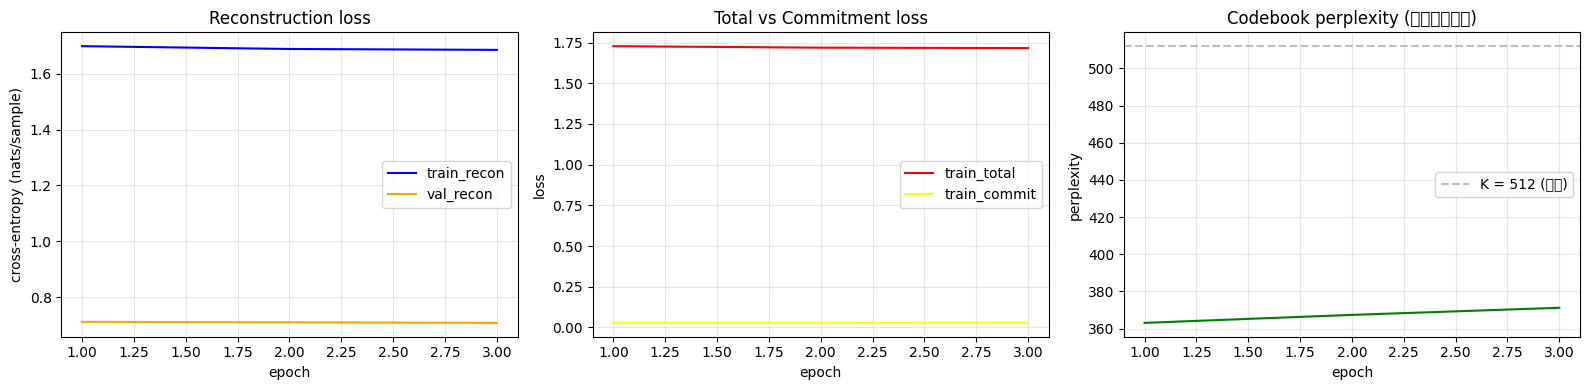

In [17]:
epochs_axis = np.arange(1, len(history["train_recon"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ---- (1) 重建损失: train vs val ----
ax = axes[0]
ax.plot(epochs_axis, history["train_recon"], "blue",   label="train_recon")
ax.plot(epochs_axis, history["val_recon"],   "orange", label="val_recon")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy (nats/sample)")
ax.set_title("Reconstruction loss")
ax.legend(); ax.grid(alpha=0.3)

# ---- (2) 总损失 vs commit ----
ax = axes[1]
ax.plot(epochs_axis, history["train_total"],  "red",    label="train_total")
ax.plot(epochs_axis, history["train_commit"], "yellow", label="train_commit")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("Total vs Commitment loss")
ax.legend(); ax.grid(alpha=0.3)

# ---- (3) Perplexity ----
ax = axes[2]
ax.plot(epochs_axis, history["train_perp"], "green")
ax.axhline(NUM_EMBEDDINGS, color="gray", linestyle="--", alpha=0.5,
           label=f"K = {NUM_EMBEDDINGS} (理想)")
ax.set_xlabel("epoch"); ax.set_ylabel("perplexity")
ax.set_title("Codebook perplexity (用得越多越好)")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5. 模型重建测试

> **关键提示**：WaveNet 解码器是**自回归**的——真正生成 `T` 个采样点需要 `T` 次 forward。对于 `T=16000` (1 秒)，即使在 CUDA 上也要跑几分钟。所以本节提供两种验证方式：
>
> | 模式 | 速度 | 含义 | 用在 |
> |---|---|---|---|
> | **teacher-forced** (默认) | O(1) forward | 已知"每一时刻之前的 GT 样本"时模型会预测什么 | 5.1 / 5.2 |
> | **autoregressive** | O(T) forward | 真正从 latent 自回归生成波形 | 5.3 voice conversion (没有 GT 可以 teacher force) |
>
> 想体验真自回归重建，把 5.1 里的 `teacher_forced=False`、同步把 `DEMO_T` 调小到 2000~4000 即可。

工具都在 `Train.py` 里：
- `Train.reconstruct_audio(...)`：两种模式的重建，返回 μ-law 整数
- `Train.draw_audio(...)`：上原图 / 下重建的双行波形对比
- `Train.codebook_usage_audio(...)`：扫一遍数据集，给出 counts / usage_ratio / perplexity
- `Train.voice_convert_audio(...)`：encode A → decode B

### 5.1 重建听感 + 波形对比

流程：

1. 用 `GetData.pick_speechy_samples_from_loader(test_loader, ...)` 从 test 集里挑 **RMS 能量较高** 的若干条（避免 valid/test 固定从文件头截 1 秒时落到 leading silence）。
2. 调用 `Train.reconstruct_audio(model, wf, mu, spk, device, teacher_forced=True)` 拿到重建的 μ-law 整数（默认 teacher-forced，快）。
3. `mu_law_decode` 把整数解回浮点波形，方便绘图 / 试听。
4. `Train.draw_audio` 画上下两排波形对比。
5. 用 `IPython.display.Audio` 直接听原始 vs 重建。

形状链路：

```
wf  (B, T) float   →┐
mu  (B, T) long    │→  Train.reconstruct_audio → mu_recon (B, T) long
spk (B,)   long    →┘                                   ↓
                                            mu_law_decode → wf_recon (B, T) float
```

[pick_speechy_samples] 选中 3 条 | RMS=[0.1168, 0.0976, 0.0815]
batch: wf(3, 8000)  mu(3, 8000)  spk(3,)
mu_recon: (3, 8000) torch.int64 range=[22, 242]
wf_recon: (3, 8000) torch.float32


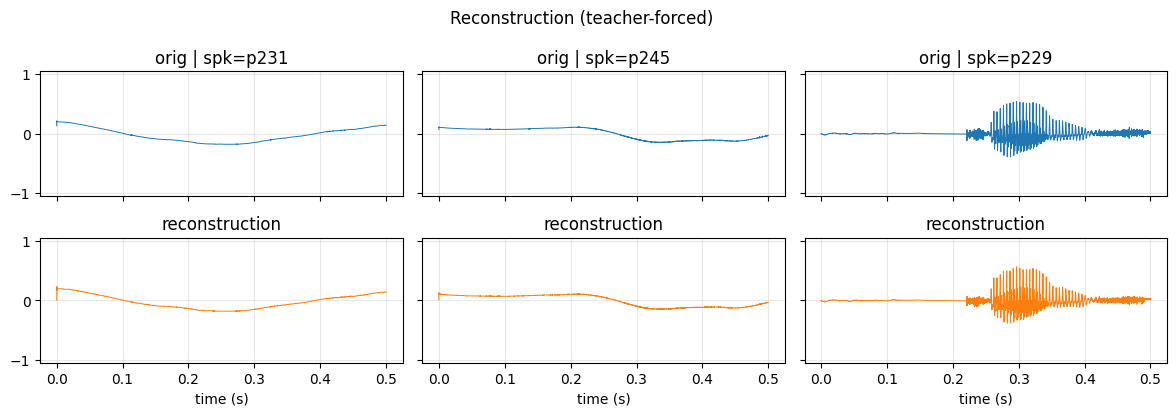


样本 0  speaker=p231
  原始 (float):


  重建 (teacher-forced):



样本 1  speaker=p245
  原始 (float):


  重建 (teacher-forced):



样本 2  speaker=p229
  原始 (float):


  重建 (teacher-forced):


In [18]:
# vqvae_model=init_model
N_SHOW = 3

# ---- (1) 挑有语音的样本 (test 集 random_crop=False, 直接 next(iter) 易截到开头静音) ----
# 形状: wf_test (N_SHOW, T) float, mu_test (N_SHOW, T) long, spk_test (N_SHOW,) long
wf_test, mu_test, spk_test = GetData.pick_speechy_samples_from_loader(
    test_loader,
    n           = N_SHOW,
    min_rms     = 0.02,   # 可调; 越小越宽松
    max_batches = 50,     # 最多扫描 50 个 batch
)
print(f"batch: wf{tuple(wf_test.shape)}  mu{tuple(mu_test.shape)}  spk{tuple(spk_test.shape)}")

# ---- (2) 重建 (teacher-forced, 一次 forward, 快) ----
# 返回 (B, T) long 的 μ-law 整数
mu_recon = Train.reconstruct_audio(
    model           = vqvae_model,
    waveform_float  = wf_test,
    waveform_mulaw  = mu_test,
    speaker_id      = spk_test,
    device          = device,
    teacher_forced  = True,
)
print(f"mu_recon: {tuple(mu_recon.shape)} {mu_recon.dtype} "
      f"range=[{mu_recon.min().item()}, {mu_recon.max().item()}]")

# ---- (3) μ-law -> 浮点波形, 方便画图与试听 ----
wf_recon = mu_law_decode(mu_recon.cpu(), MU_LAW_CHANNELS)        # (B, T) float ∈ [-1,1]
print(f"wf_recon: {tuple(wf_recon.shape)} {wf_recon.dtype}")

# ---- (4) 画波形对比 (上排原始 / 下排重建) ----
spk_names = [id_to_speaker[i.item()] for i in spk_test[:N_SHOW]]
Train.draw_audio(
    wf_orig_float  = wf_test,
    wf_recon_float = wf_recon,
    sample_rate    = SAMPLE_RATE,
    n              = N_SHOW,
    speaker_names  = spk_names,
    title          = "Reconstruction (teacher-forced)",
)

# ---- (5) 试听: 原始 vs 重建 ----
for i in range(min(3, N_SHOW)):
    print(f"\n样本 {i}  speaker={spk_names[i]}")
    print("  原始 (float):")
    display(Audio(wf_test[i].numpy(),  rate=SAMPLE_RATE))
    print("  重建 (teacher-forced):")
    display(Audio(wf_recon[i].numpy(), rate=SAMPLE_RATE))

### 5.2 码本利用率与客观指标 *(补充)*

VQ-VAE 训得好不好，一个客观信号是**码本是否被充分使用**。这里给两个数：

- **`usage_ratio`**：valid 集上至少出现过一次的码字数 / `K`；越接近 1 越好。
- **`perplexity`**：valid 集 token 分布的 perplexity = `exp(-Σ pₖ log pₖ)`；越接近 `K` 说明 token 分布越均匀，越远离 `K`（特别是接近 1）就是 codebook collapse。

底层逻辑已经封装在 `Train.codebook_usage_audio` 里，它对 `data_loader` 遍历，调用 `model.encode` 拿 `(B, T_lat)` 的 indices，再用 `torch.bincount` 累计直方图。

valid 上 token 总数 : 545875
used / K            : 511 / 512
usage_ratio         : 99.8%  (越接近 100% 越好)
codebook perplexity : 198.0  (理想 ~ K = 512)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\3051371997.py:35: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\3051371997.py:35: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\3051371997.py:35: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\3051371997.py:35: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\3051371997.py:35: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37828\3051371997.py:35: UserWarning: Glyph 25

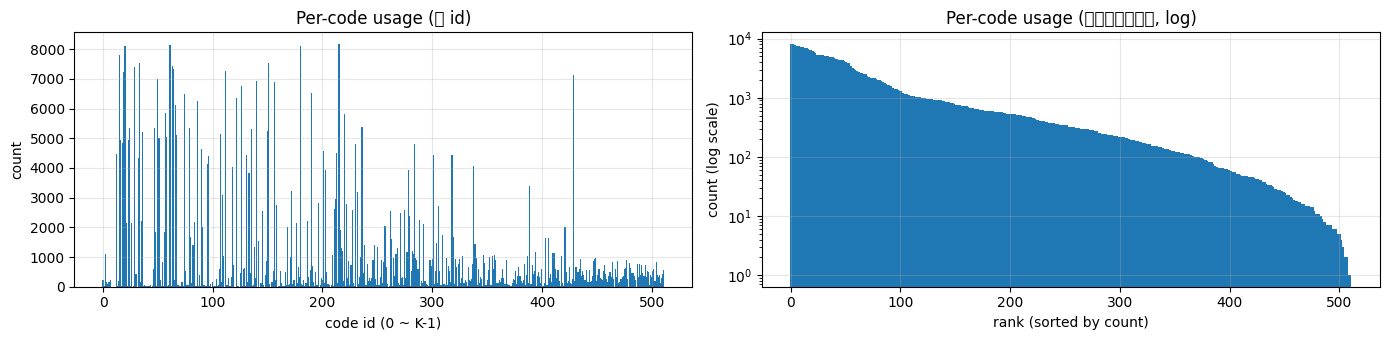

In [19]:
# ---- 统计码本使用情况 ----
counts, usage_ratio, codebook_perp = Train.codebook_usage_audio(
    model          = vqvae_model,
    data_loader    = valid_loader,
    num_embeddings = NUM_EMBEDDINGS,
    device         = device,
    max_batches    = None,    # 全部跑; 嫌慢可以填个小数比如 20
)

print(f"valid 上 token 总数 : {int(counts.sum().item())}")
print(f"used / K            : {int((counts>0).sum().item())} / {NUM_EMBEDDINGS}")
print(f"usage_ratio         : {usage_ratio*100:.1f}%  (越接近 100% 越好)")
print(f"codebook perplexity : {codebook_perp:.1f}  (理想 ~ K = {NUM_EMBEDDINGS})")

# ---- 画 token 分布柱状图 ----
# 把 counts 按从大到小排序看长尾
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# (1) 按 id 顺序
axes[0].bar(np.arange(NUM_EMBEDDINGS), counts.numpy(), width=1.0)
axes[0].set_xlabel("code id (0 ~ K-1)")
axes[0].set_ylabel("count")
axes[0].set_title("Per-code usage (按 id)")
axes[0].grid(alpha=0.3)

# (2) 按使用次数从大到小
sorted_counts = torch.sort(counts, descending=True).values.numpy()
axes[1].bar(np.arange(NUM_EMBEDDINGS), sorted_counts, width=1.0)
axes[1].set_xlabel("rank (sorted by count)")
axes[1].set_ylabel("count (log scale)")
axes[1].set_yscale("log")
axes[1].set_title("Per-code usage (按使用频率排序, log)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 语者转换 (voice conversion) demo *(补充，原论文最有特色的实验)*

VQ-VAE 在音频上最出彩的能力：**编码端拿说话人 A 的一句话，解码端把 `speaker_id` 换成 B**，输出应该是"B 用自己的声音说出 A 的内容"。

```
wf_A  ─Encoder─►  tokens  ─Decoder( spk = B )─►  wf_BA
        (A的音色被 z 抠掉,
         只剩 phoneme 内容)
```

**重要**：这一节必须用**真正的自回归生成**（`teacher_forced=False`），因为我们没有 B 的 GT 波形可以拿来 teacher force。autoregressive 一次 forward 是 1 个采样点，T 个采样点要 T 次 forward——

- T=16000 (1s)  → 实测大概几分钟一次（CUDA, 看模型大小）
- T=4000 (0.25s) → 几十秒一次

所以下面默认用 `DEMO_T=6400`：从 **RMS 能量较高** 的 test 样本里截取一段做 voice conversion 演示（`GetData.pick_speechy_samples_from_loader`）。等想要长样本时把 `DEMO_T` 调大即可。

[pick_speechy_samples] 选中 1 条 | RMS=[0.1692]
source speaker = p225 (id=0)
target speaker = p226 (id=1)

[自回归生成中 - 重建 A]  (慢)
[自回归生成中 - A→B 转换]  (慢)

indices shape : (1, 100)    (DEMO_T / DOWNSAMPLE_FACTOR = 100)


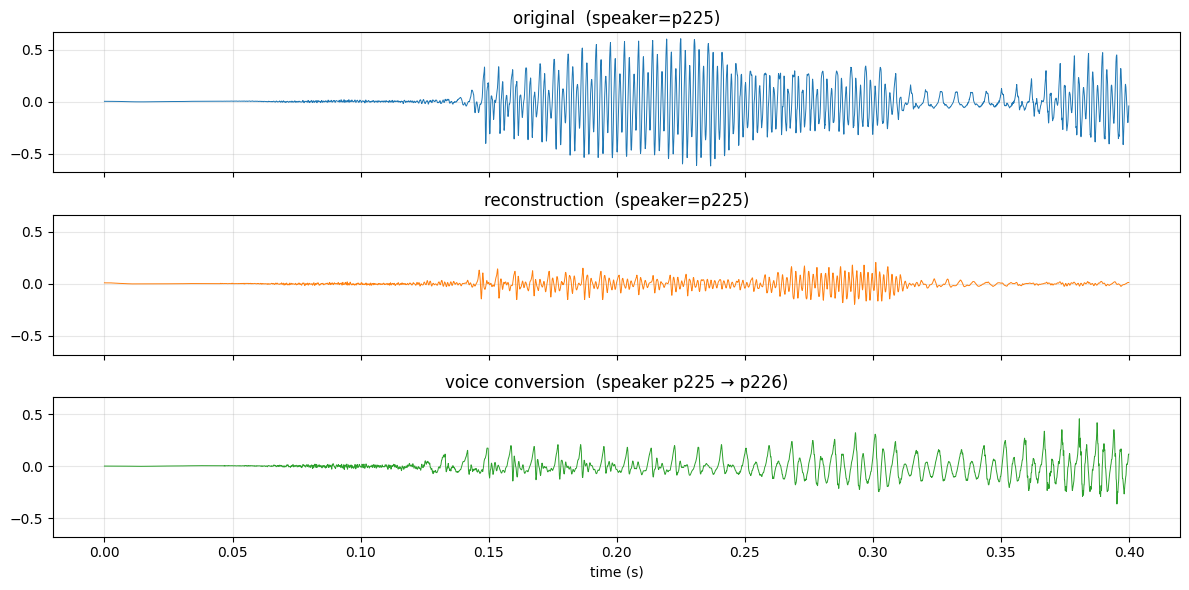


[原始 A]


[重建 A]


[A→B 转换]


In [22]:
# ============================================================
# voice conversion 演示
# 注意: 真自回归非常慢, 这里截取一小段做 demo
# ============================================================
DEMO_T = 6400     # 必须是 DOWNSAMPLE_FACTOR 的整数倍
assert DEMO_T % DOWNSAMPLE_FACTOR == 0

# ---- (1) 从 test 集挑一条 RMS 较高的 source (避免 head crop 的 leading silence) ----
wf_src, _mu_src, spk_src = GetData.pick_speechy_samples_from_loader(
    train_loader,
    n           = 1,
    min_rms     = 0.02,
    max_batches = 50,
)
src_id   = spk_src[0].item()
src_name = id_to_speaker[src_id]

# 从该条样本开头截取 DEMO_T 个采样点 (已是有语音的片段)
wf_A  = wf_src[0:1, :DEMO_T]   # (1, DEMO_T)
spk_A = spk_src[0:1]           # (1,)
print(f"source speaker = {src_name} (id={src_id})")

# ---- (2) 选一个不同的目标 speaker ----
# 从 speaker_map 里随便挑一个不等于 src_id 的
candidate_ids = [i for i in id_to_speaker.keys() if i != src_id]
tgt_id   = candidate_ids[0]
tgt_name = id_to_speaker[tgt_id]
spk_B = torch.tensor([tgt_id], dtype=torch.long)
print(f"target speaker = {tgt_name} (id={tgt_id})")

# ---- (3a) 重建 (speaker 不变, 自回归): A 的内容 + A 的音色 ----
print("\n[自回归生成中 - 重建 A]  (慢)")
mu_AA, indices_A = Train.voice_convert_audio(
    model              = vqvae_model,
    waveform_float     = wf_A,
    target_speaker_id  = spk_A,
    device             = device,
)
wf_AA = mu_law_decode(mu_AA.cpu(), MU_LAW_CHANNELS)

# ---- (3b) Voice conversion (speaker 换成 B, 自回归): A 的内容 + B 的音色 ----
print("[自回归生成中 - A→B 转换]  (慢)")
mu_BA, _ = Train.voice_convert_audio(
    model              = vqvae_model,
    waveform_float     = wf_A,
    target_speaker_id  = spk_B,
    device             = device,
)
wf_BA = mu_law_decode(mu_BA.cpu(), MU_LAW_CHANNELS)

print(f"\nindices shape : {tuple(indices_A.shape)}    "
      f"(DEMO_T / DOWNSAMPLE_FACTOR = {DEMO_T // DOWNSAMPLE_FACTOR})")

# ---- (4) 画三条波形 ----
t_axis = np.arange(DEMO_T) / SAMPLE_RATE
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True, sharey=True)
axes[0].plot(t_axis, wf_A[0].numpy(),  linewidth=0.7);                axes[0].set_title(f"original  (speaker={src_name})"); axes[0].grid(alpha=0.3)
axes[1].plot(t_axis, wf_AA[0].numpy(), linewidth=0.7, color="tab:orange"); axes[1].set_title(f"reconstruction  (speaker={src_name})"); axes[1].grid(alpha=0.3)
axes[2].plot(t_axis, wf_BA[0].numpy(), linewidth=0.7, color="tab:green");  axes[2].set_title(f"voice conversion  (speaker {src_name} → {tgt_name})"); axes[2].grid(alpha=0.3)
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

# ---- (5) 三段试听 ----
print("\n[原始 A]"); display(Audio(wf_A[0].numpy(),  rate=SAMPLE_RATE))
print(f"[重建 A]"); display(Audio(wf_AA[0].numpy(), rate=SAMPLE_RATE))
print(f"[A→B 转换]"); display(Audio(wf_BA[0].numpy(), rate=SAMPLE_RATE))

# 6. Token 数据集缓存 *(补充)*

阶段二（先验训练）的输入就是 VQ-VAE 编码出来的 `(B, T_lat)` 离散 token 序列。第 4 节训完后 VQ-VAE 已经冻结，所以**完全没必要**在先验训练的每个 epoch 都重新跑一次 Encoder：

| 路径 | 单 epoch 开销 |
|---|---|
| 实时跑：wav → DataLoader (读盘 + 重采样 + 裁剪) → Encoder (6 层 stride=2 1D conv) → token | 慢 |
| 直接读：磁盘 `(N, T_lat)` `long` 张量 → token | 接近零开销 |

token 体积只有原始 16 kHz `float32` 波形的 `1/64 × (8/4) ≈ 1/32`（每个 token 是 `int64`），磁盘 / 显存都可以忽略。

> 对齐图像版 `vqvae_indices_dataset.pt` 的做法，这里把训练 / 验证集各编码一遍，写到 `..\checkpoints\vqvae_audio_token_dataset.pt`，后续 7.1 直接 `torch.load` 包成 `TensorDataset`。
>
> **搜索 → 加载 / 重算** 模式（沿用 4.1 的写法）：
> - 已有缓存且 config 完全匹配（`NUM_EMBEDDINGS`、`TOKEN_LEN`、`NUM_SPEAKERS`、`DOWNSAMPLE_FACTOR` 都一致）→ 直接读盘，跳过 encode；
> - 任一项变了 → 重新 encode 并覆盖磁盘。
>
> **形状链路**：
> ```
> batch wf_float (B, T=16000) ──vqvae_model.encode──► tokens (B, T_lat=250) long ∈ [0, K-1]
>                                                                │
>                              所有 batch 在 batch 维 cat ───────►  (N, T_lat)
>                                                                │
>                                                       torch.save → 磁盘
> ```

In [26]:
# ============================================================
# (1) 缓存文件路径 + encode 工具函数
# ------------------------------------------------------------
#   TOKEN_CACHE_PATH : 单一磁盘文件 (dict 形式), 一次 load 就能取回 train/valid
#                      两个 split 的 token + speaker, 加上一份 config 元数据.
#   _encode_loader   : 把任意一个 DataLoader 跑一遍 encode, 累计到 CPU 后拼成
#                      单个张量返回. 抽出来是为了 train/valid 复用同一份逻辑.
# ============================================================
TOKEN_CACHE_PATH = os.path.join(SAVE_DIR, "vqvae_audio_token_dataset.pt")


def _encode_loader(model, loader, device, desc=""):
    """
    遍历 loader, 用 model.encode 把每个 batch 的浮点波形压成 token 序列,
    全部 .cpu() 累计后在 batch 维 cat 成一个大张量.

    参数
    ----------
    model  : Model.AudioVQVAE
        已加载最佳权重的 VQ-VAE (第 4 节训完且冻结). 函数内会再次 .eval()
        关掉 BN / Dropout 的训练态行为, 保证 encode 结果可复现.
    loader : torch.utils.data.DataLoader
        每个 batch yield 三元组 (waveform_float, waveform_mulaw, speaker_id),
        来自 GetData.AudioFolderDataset:
          - waveform_float : (B, T=SEGMENT_SAMPLES) float32, ∈ [-1, 1]   <- 我们要用
          - waveform_mulaw : (B, T)                  long,  ∈ [0, 255]   <- encode 用不到
          - speaker_id     : (B,)                    long,  ∈ [0, NUM_SPEAKERS-1]
    device : str
        encode forward 跑在哪台设备 ("cuda:0" / "cpu"). speaker_id 这里不参与
        encode (encode 只依赖波形), 所以留在 CPU 即可省一次 host→device 拷贝.
    desc   : str
        tqdm 进度条左侧标题, 用来区分 "encode train" / "encode valid".

    返回
    ----------
    tokens   : (N, T_lat) long, CPU. 取值 0 .. NUM_EMBEDDINGS-1.
    speakers : (N,)        long, CPU. 取值 0 .. NUM_SPEAKERS-1.
        N 与 loader 配置有关:
          - train_loader (drop_last=True ) : N = BATCH_SIZE * len(loader)
          - valid_loader (drop_last=False) : N = len(loader.dataset)
    """
    # 即便 4.3 已 .eval() 过, 这里再保险一次, 防止外部不小心 .train() 又改回来
    model.eval()

    token_buf, spk_buf = [], []

    # torch.no_grad() : 推理不需要梯度计算图, 显存 / 速度都更友好
    with torch.no_grad():
        for wf_float, _wf_mulaw, spk in tqdm(loader, desc=desc):
            # wf_float : (B, T) float, 送上 device 做 forward
            # model.encode 内部: unsqueeze 通道 -> 1D Encoder 下采样 64× -> VQ argmax
            # 输出 idx : (B, T_lat) long, 仍在 device 上
            idx = model.encode(wf_float.to(device))

            # 立刻搬回 CPU 释放显存; 否则整套数据集累计在 GPU 上几个 GB 会爆
            token_buf.append(idx.cpu())
            spk_buf.append(spk)        # 本来就是 CPU long, 直接附上

    # 在 batch 维 (dim=0) 把所有 batch 拼起来:
    #   token_buf : List[(B_i, T_lat)] -> tokens   (sum(B_i), T_lat)
    #   spk_buf   : List[(B_i,)]       -> speakers (sum(B_i),)
    tokens   = torch.cat(token_buf, dim=0)
    speakers = torch.cat(spk_buf,   dim=0)
    return tokens, speakers


# ============================================================
# (2) 搜索磁盘缓存
# ------------------------------------------------------------
# 检查 TOKEN_CACHE_PATH 是否已有可直接复用的缓存. 任一关键 config 不匹配都重算:
#   - NUM_EMBEDDINGS    : 码本大小 K, 变了之后 token 的取值空间整体变了
#   - TOKEN_LEN         : 单条样本压完后的时间步数 = SEGMENT_SAMPLES / DOWNSAMPLE_FACTOR
#   - NUM_SPEAKERS      : 说话人数, 决定 speaker_id 的取值上界
#   - DOWNSAMPLE_FACTOR : 下采样倍率, 决定 TOKEN_LEN 的物理含义
# ============================================================
need_encode = True   # 是否需要重新跑 encode 写盘
if os.path.isfile(TOKEN_CACHE_PATH):
    print(f"[token cache] 发现已有缓存: {TOKEN_CACHE_PATH}")
    # weights_only=False : 我们存的是 dict (张量 + python 标量), 不是纯 state_dict;
    #                      新版 torch 默认 weights_only=True 会拒绝 pickle, 要显式关掉.
    _cache = torch.load(TOKEN_CACHE_PATH, map_location="cpu", weights_only=False)
    _cfg = _cache.get("config", {})
    _ok = (
        _cfg.get("NUM_EMBEDDINGS")    == NUM_EMBEDDINGS
        and _cfg.get("TOKEN_LEN")     == TOKEN_LEN
        and _cfg.get("NUM_SPEAKERS")  == NUM_SPEAKERS
        and _cfg.get("DOWNSAMPLE_FACTOR") == DOWNSAMPLE_FACTOR
    )
    if _ok:
        # 命中 -> 直接拿出来用, 跳过 (3) 的 encode
        train_tokens   = _cache["train_tokens"]
        train_speakers = _cache["train_speakers"]
        valid_tokens   = _cache["valid_tokens"]
        valid_speakers = _cache["valid_speakers"]
        need_encode = False
        print("              config 匹配, 直接读磁盘 (跳过 encode)")
    else:
        print("              config 不匹配, 将重新 encode 并覆盖")
else:
    print(f"[token cache] 未发现缓存, 将编码并写入 {TOKEN_CACHE_PATH}")


# ============================================================
# (3) 没缓存 / 不匹配 -> 跑一遍 encode 并保存
# ------------------------------------------------------------
# 注意:
#   - train_loader shuffle=True, 每次 iter 顺序都不同; 但 (tokens[i], speakers[i])
#     是同一时刻取出来的 pair, 顺序对训练没有影响 (TensorDataset 再次随机访问).
#   - valid_loader shuffle=False, 顺序固定; 便于以后对 valid 集做可重复的可视化.
# ============================================================
if need_encode:
    # ---- (3a) 编码 train + valid ----
    train_tokens, train_speakers = _encode_loader(
        vqvae_model, train_loader, device, desc="encode train"
    )
    valid_tokens, valid_speakers = _encode_loader(
        vqvae_model, valid_loader, device, desc="encode valid"
    )

    # ---- (3b) 写盘 ----
    # 用 dict 一次性 torch.save, 一条 torch.load 就能取回所有内容, 比拆成 4 个文件好管理.
    # 同时存一份 config, (2) 下次启动可据此校验.
    torch.save(
        {
            "train_tokens"   : train_tokens,     # (N_train, T_lat) long
            "train_speakers" : train_speakers,   # (N_train,)        long
            "valid_tokens"   : valid_tokens,     # (N_valid, T_lat) long
            "valid_speakers" : valid_speakers,   # (N_valid,)        long
            "config": {
                "NUM_EMBEDDINGS"    : NUM_EMBEDDINGS,
                "TOKEN_LEN"         : TOKEN_LEN,
                "NUM_SPEAKERS"      : NUM_SPEAKERS,
                "DOWNSAMPLE_FACTOR" : DOWNSAMPLE_FACTOR,
                "SEGMENT_SAMPLES"   : SEGMENT_SAMPLES,
                "SAMPLE_RATE"       : SAMPLE_RATE,
            },
        },
        TOKEN_CACHE_PATH,
    )
    print(f"[token cache] 已写入: {TOKEN_CACHE_PATH}")


# ============================================================
# (4) Sanity check + 统计信息
# ------------------------------------------------------------
# 不管走的是缓存路径还是重算路径, 这里都对最终的四个张量做一遍检查:
#   1. token 时间维 = TOKEN_LEN  (= SEGMENT_SAMPLES / DOWNSAMPLE_FACTOR)
#   2. token 取值落在 [0, K-1]
#   3. token / speaker 第一维 (N) 完全一致, 一一配对
#   4. speaker unique 数应 == NUM_SPEAKERS  (因为切分时保证每个 speaker 都在三个集合里)
# 任何一条不满足都说明缓存或 encode 流程有 bug, assert 直接终止避免误传到下游.
# ============================================================
print()
print(f"train_tokens   : {tuple(train_tokens.shape)} {train_tokens.dtype} "
      f"range=[{train_tokens.min().item()}, {train_tokens.max().item()}]")
print(f"train_speakers : {tuple(train_speakers.shape)} {train_speakers.dtype} "
      f"unique={train_speakers.unique().numel()} / {NUM_SPEAKERS}")
print(f"valid_tokens   : {tuple(valid_tokens.shape)} {valid_tokens.dtype} "
      f"range=[{valid_tokens.min().item()}, {valid_tokens.max().item()}]")
print(f"valid_speakers : {tuple(valid_speakers.shape)} {valid_speakers.dtype} "
      f"unique={valid_speakers.unique().numel()} / {NUM_SPEAKERS}")

assert train_tokens.size(1) == TOKEN_LEN, \
    f"train_tokens 时间维 {train_tokens.size(1)} != TOKEN_LEN {TOKEN_LEN}"
assert valid_tokens.size(1) == TOKEN_LEN, \
    f"valid_tokens 时间维 {valid_tokens.size(1)} != TOKEN_LEN {TOKEN_LEN}"
assert train_tokens.max().item() < NUM_EMBEDDINGS, "train_tokens 出现越界 token id"
assert valid_tokens.max().item() < NUM_EMBEDDINGS, "valid_tokens 出现越界 token id"
assert train_tokens.min().item() >= 0, "train_tokens 出现负 token id"
assert valid_tokens.min().item() >= 0, "valid_tokens 出现负 token id"
assert train_tokens.size(0) == train_speakers.size(0), "train 的 token / speaker 行数不一致"
assert valid_tokens.size(0) == valid_speakers.size(0), "valid 的 token / speaker 行数不一致"
print("[sanity] shape / range / count OK")

# 磁盘体积提示 (long 张量 8 bytes/token, 通常几十 MB 量级, 远小于原 wav 数据集)
_size_mb = os.path.getsize(TOKEN_CACHE_PATH) / (1024 ** 2)
print(f"[disk]   {TOKEN_CACHE_PATH}  ~ {_size_mb:.2f} MB")

[token cache] 未发现缓存, 将编码并写入 ..\checkpoints\vqvae_audio_token_dataset.pt


encode valid: 100%|██████████| 546/546 [00:32<00:00, 16.55it/s]


[token cache] 已写入: ..\checkpoints\vqvae_audio_token_dataset.pt

train_tokens   : (79440, 250) torch.int64 range=[0, 486]
train_speakers : (79440,) torch.int64 unique=110 / 110
valid_tokens   : (4367, 250) torch.int64 range=[0, 486]
valid_speakers : (4367,) torch.int64 unique=110 / 110
[sanity] shape / range / count OK
[disk]   ..\checkpoints\vqvae_audio_token_dataset.pt  ~ 160.49 MB


# 7. 先验自回归生成模型训练

阶段一 VQ-VAE 已经学会"把波形压成离散 token + 按 speaker 重建"。阶段二要在**冻结的 token 空间**里学分布 \(p(z \mid \text{speaker})\)，以后才能**从零采样** token，再交给 VQ-VAE 解码成新音频。

| 对比项 | 图像版 (Generate_ex) | 音频版 (本节) |
|---|---|---|
| 先验网络 | `GatedPixelCNN` (2D 因果卷积) | `WaveNet1DPrior` (1D 因果 dilated conv) |
| 训练数据 | `vqvae_indices_dataset.pt` `(N, 32, 32)` | 第 6 节 `vqvae_audio_token_dataset.pt` `(N, T_lat)` |
| 条件 | class label (CIFAR-10) | speaker_id (VCTK 多说话人) |
| 损失 | `CrossEntropy(logits, tokens)` | 同上 |
| 训练函数 | `Train.train_prior` | `Train.train_audio_prior` |

**形状链路（训练一步）**：
```
tokens (B, T_lat) long ──right_shift──► embed ──► causal WaveNet + spk_emb ──► logits (B, K, T_lat)
                                                                                      │
                                                                         CrossEntropy │
                                                                                      ▼
                                                                            与 tokens 对齐
```

本节流程（对齐第 4 节 / 图像版 Generate_ex）：

| 子节 | 做什么 |
|---|---|
| 7.1 | 用第 6 节缓存的 `train_tokens / train_speakers` 包成 `TensorDataset` + `DataLoader` |
| 7.2 | 定义先验超参 + `build_audio_prior()` 工厂 + 冒烟前向 |
| 7.3.1 | 搜索 `best_audio_prior.pt`，有则加载作 fine-tune 起点 |
| 7.3.2 | 调用 `Train.train_audio_prior` 跑 `PRIOR_EPOCHS` 轮 |
| 7.3.3 | 只有 `val_loss` 刷新历史最佳才覆盖 checkpoint |
| 7.4 | 画 train / val CE 曲线 |

### 7.1 构建 token DataLoader

第 6 节已经把 `train_loader / valid_loader` 整集 encode 成 CPU 上的 `(N, T_lat)` 张量。先验训练**不再读 wav**，直接在这些张量上随机取 batch 即可。

`torch.utils.data.TensorDataset(*tensors)` 会把多个**第一维长度相同**的张量绑成一条样本：`dataset[i] == (tensors[0][i], tensors[1][i], ...)`。我们这里绑 `(token_i, speaker_i)`，保证二者始终配对。

`DataLoader(dataset, batch_size, shuffle, ...)` 负责：
- `shuffle=True`（训练）：每个 epoch 打乱样本顺序，避免模型记住文件顺序；
- `shuffle=False`（验证）：顺序固定，便于复现；
- `pin_memory=True`：张量在 pinned memory 上，`.to("cuda")` 更快（对大 batch 有帮助）。

In [ ]:
# TensorDataset 在 1.1 只 import 了 DataLoader/Dataset, 这里单独引入
from torch.utils.data import TensorDataset

# ============================================================
# (1) 用第 6 节产出的四个张量构建 Dataset
# ------------------------------------------------------------
#   train_tokens   : (N_train, T_lat) long  —— 每条 ~1s 音频对应的离散 token 序列
#   train_speakers : (N_train,)        long  —— 与 train_tokens 同行一一对应
#   valid_tokens   : (N_valid, T_lat) long
#   valid_speakers : (N_valid,)        long
# ============================================================
token_train_set = TensorDataset(train_tokens, train_speakers)
token_valid_set = TensorDataset(valid_tokens, valid_speakers)

# ============================================================
# (2) 包成 DataLoader
# ------------------------------------------------------------
#   PRIOR_BATCH_SIZE : 可与 VQ-VAE 的 BATCH_SIZE 相同; 先验只有 Embedding+1D conv,
#                      显存通常比 WaveNet 解码器小, 32 一般够用.
#   num_workers=2    : token 数据已在 CPU 内存, 开 worker 能加速 shuffle + batch
# ============================================================
PRIOR_BATCH_SIZE = BATCH_SIZE   # 复用 1.2 的全局 batch size (默认 32)

token_train_loader = DataLoader(
    token_train_set,
    batch_size=PRIOR_BATCH_SIZE,
    shuffle=True,               # 训练必须 shuffle
    num_workers=2,
    pin_memory=True,
    drop_last=True,             # 与 train_loader 对齐, 每个 batch 形状固定 (B, T_lat)
)
token_valid_loader = DataLoader(
    token_valid_set,
    batch_size=PRIOR_BATCH_SIZE,
    shuffle=False,              # 验证不打乱
    num_workers=2,
    pin_memory=True,
    drop_last=False,            # 验证集保留最后一个不满 batch
)

# ============================================================
# (3) Sanity check: 取一个 batch 看形状
# ------------------------------------------------------------
# next(iter(loader)) 从 DataLoader 里拿出**第一个** batch (训练集 shuffle 后顺序随机)
# ============================================================
_tok_b, _spk_b = next(iter(token_train_loader))
print(f"token_train_loader : {len(token_train_loader)} batches  (dataset={len(token_train_set)})")
print(f"token_valid_loader : {len(token_valid_loader)} batches  (dataset={len(token_valid_set)})")
print(f"sample batch       : tokens{tuple(_tok_b.shape)} {_tok_b.dtype}  "
      f"spk{tuple(_spk_b.shape)} {_spk_b.dtype}")
print(f"  token range      : [{_tok_b.min().item()}, {_tok_b.max().item()}]  (应 ∈ [0, {NUM_EMBEDDINGS-1}])")
print(f"  speaker range    : [{_spk_b.min().item()}, {_spk_b.max().item()}]  (应 ∈ [0, {NUM_SPEAKERS-1}])")

assert _tok_b.ndim == 2 and _tok_b.size(1) == TOKEN_LEN
assert _spk_b.ndim == 1 and _spk_b.size(0) == _tok_b.size(0)
assert _tok_b.max().item() < NUM_EMBEDDINGS
print("[sanity] token DataLoader OK")

### 7.2 实例化 1D 先验 WaveNet

`Model.WaveNet1DPrior` 在 `Model.py` 末尾实现，接口与图像版 `GatedPixelCNN` 类似，只是维度从 2D 换成 1D：

| 参数 | 含义 |
|---|---|
| `vocab_size` | 码本大小 K = `NUM_EMBEDDINGS`，Embedding 行数 & 输出 logits 的类别数 |
| `dim` | 中间通道宽度，越大表达能力越强、越慢 |
| `n_layers` | 堆叠多少个 `WaveNetBlock`；内部 dilation 按 `2^(i % 8)` 周期增长 |
| `kernel_size` | 因果卷积核宽，典型 3 |
| `num_speakers` | 说话人总数，决定 `nn.Embedding(num_speakers, speaker_dim)` |
| `speaker_dim` | 与 VQ-VAE 解码器共用的 speaker 向量维度（复用 `SPEAKER_DIM`） |

**前向要点**：输入 token 先做 `_right_shift`（把序列右移一位、首位填 0），这样位置 `t` 的 logits 只依赖 `tokens[0..t-1]`，不会"偷看"当前真值——与 WaveNet 解码器、PixelCNN 的训练策略一致。

下面先定义先验专属超参 + 工厂函数，再跑一次冒烟前向确认 `(B, T_lat) → (B, K, T_lat)`。

In [ ]:
# ============================================================
# 先验 WaveNet 专属超参 (放在这里, 不污染 1.2 的 VQ-VAE 表)
# ------------------------------------------------------------
#   PRIOR_DIM    : 每层残差 / skip 通道数 (Model 里 residual_channels=skip_channels=dim)
#   PRIOR_LAYERS : WaveNetBlock 层数; dilation 周期 8 -> 有效感受野随层数增大
#   PRIOR_KERNEL : 因果卷积核宽
#   PRIOR_EPOCHS / PRIOR_PRINT_EPOC / PRIOR_LR / PRIOR_WD : 训练调度
# ============================================================
PRIOR_DIM         = 128
PRIOR_LAYERS      = 20          # 小机器先用 20 层; 论文级可加到 30+
PRIOR_KERNEL      = 3
PRIOR_EPOCHS      = 100
PRIOR_PRINT_EPOC  = 5
PRIOR_LR          = 2e-4
PRIOR_WD          = 0.0


def build_audio_prior():
    """
    工厂方法: 保证 7.3 加载 ckpt 与 8.1 冷启动重建时, 网络结构与训练时完全一致.
    返回未 .to(device) 的 CPU 模型, 调用方自行 .to(device).
    """
    return Model.WaveNet1DPrior(
        vocab_size   = NUM_EMBEDDINGS,   # K, token 取值上界 + 输出类别数
        dim          = PRIOR_DIM,        # 中间通道
        n_layers     = PRIOR_LAYERS,     # block 数
        kernel_size  = PRIOR_KERNEL,     # 因果卷积核宽 (注意参数名是 kernel_size)
        num_speakers = NUM_SPEAKERS,
        speaker_dim  = SPEAKER_DIM,      # 与 VQ-VAE 解码器共用, 便于以后联合理解
    )


# ---- 冒烟前向: 确认 logits 形状与 CE 能对上 ----
_tmp_prior = build_audio_prior().to(device)
_n_prior_params = sum(p.numel() for p in _tmp_prior.parameters())
print(f"WaveNet1DPrior params: {_n_prior_params/1e6:.2f} M")

with torch.no_grad():
    _tok, _spk = next(iter(token_train_loader))
    _tok = _tok.to(device)                     # (B, T_lat)
    _spk = _spk.to(device)                     # (B,)
    _logits = _tmp_prior(_tok, _spk)           # (B, K, T_lat)
    print(f"forward shapes : tokens{tuple(_tok.shape)}  spk{tuple(_spk.shape)}  "
          f"-> logits{tuple(_logits.shape)}")
    # CrossEntropyLoss 要求 target 与 logits 时间维一致
    _ce = F.cross_entropy(_logits, _tok)
    print(f"smoke CE loss  : {_ce.item():.4f}  (随机初始化, 应约 ln(K)≈{np.log(NUM_EMBEDDINGS):.2f})")

del _tmp_prior, _tok, _spk, _logits, _ce
if device.startswith("cuda"):
    torch.cuda.empty_cache()

### 7.3.1 初始化先验 + 搜索 / 加载已有 checkpoint

逻辑对齐第 4.1 节 VQ-VAE：
1. `build_audio_prior()` 新建一份网络；
2. 若 `PRIOR_CKPT_PATH` 存在 → `torch.load` 读权重 + `best_loss`，作为 fine-tune 起点；
3. 否则从零开始（历史 best = +inf）。

In [ ]:
PRIOR_CKPT_PATH = os.path.join(SAVE_DIR, "best_audio_prior.pt")

# ---- (1) 新建先验模型 ----
init_prior = build_audio_prior().to(device)

# ---- (2) 搜索是否已有 best ckpt ----
prev_best_prior_loss = float("inf")
if os.path.isfile(PRIOR_CKPT_PATH):
    print(f"[prior ckpt] 发现已有最佳模型: {PRIOR_CKPT_PATH}")
    _prior_ckpt = torch.load(PRIOR_CKPT_PATH, map_location=device, weights_only=False)
    init_prior.load_state_dict(_prior_ckpt["model_state_dict"])
    prev_best_prior_loss = _prior_ckpt.get("best_loss", float("inf"))
    print(f"             prev best val CE = {prev_best_prior_loss:.4f}")
    print(f"             将从这份权重继续训练 {PRIOR_EPOCHS} 个 epoch")
else:
    print(f"[prior ckpt] 未发现已有 ckpt, 从零开始训练")
    print(f"             prev best val CE = +inf  (任何结果都将尝试保存)")

### 7.3.2 训练先验模型

调用 `Train.train_audio_prior`（定义在 `Train.py`，由图像版 `train_prior` 改写而来）：

- 每个 batch：`(tokens, spk)` → `prior(tokens, spk)` → `logits (B, K, T_lat)`；
- `nn.CrossEntropyLoss(logits, tokens)`：对序列每个位置做 K 类分类；
- 内部按 **val_loss 最小** 保留 `best_state`，函数返回时 `init_prior` 已 load 最佳权重。

In [ ]:
prior_model, prior_train_loss_list, prior_val_loss_list = Train.train_audio_prior(
    init_model     = init_prior,
    train_loader   = token_train_loader,
    valid_loader   = token_valid_loader,
    epochs         = PRIOR_EPOCHS,
    print_epoc     = PRIOR_PRINT_EPOC,
    lr             = PRIOR_LR,
    wd             = PRIOR_WD,
    device         = device,
)

# train_audio_prior 返回的 prior_model 已是验证集最优权重
cur_best_prior_loss = min(prior_val_loss_list) if len(prior_val_loss_list) > 0 else float("inf")
print(f"\n[train] 本次训练 {PRIOR_EPOCHS} epoch 结束")
print(f"        本次 best val CE = {cur_best_prior_loss:.4f}  "
      f"(训练前历史 best {prev_best_prior_loss:.4f})")

### 7.3.3 对比 & 保存真正的最佳先验

只有当 `cur_best_prior_loss < prev_best_prior_loss` 时才覆盖 `best_audio_prior.pt`；否则保留旧文件。

保存内容对齐图像版 `best_pixelcnn_prior.pt`：`model_state_dict / config / train_loss_list / valid_loss_list / best_loss`。

> 第 8 节会用到变量 `prior_model`（无论是否覆盖磁盘，都保证是**当前训练跑完后的验证最优**）。

In [ ]:
prior_model.eval()

prior_config = {
    "NUM_EMBEDDINGS" : NUM_EMBEDDINGS,
    "TOKEN_LEN"      : TOKEN_LEN,
    "NUM_SPEAKERS"   : NUM_SPEAKERS,
    "SPEAKER_DIM"    : SPEAKER_DIM,
    "PRIOR_DIM"      : PRIOR_DIM,
    "PRIOR_LAYERS"   : PRIOR_LAYERS,
    "PRIOR_KERNEL"   : PRIOR_KERNEL,
}

if cur_best_prior_loss < prev_best_prior_loss:
    torch.save({
        "model_state_dict" : prior_model.state_dict(),
        "config"           : prior_config,
        "train_loss_list"  : prior_train_loss_list,
        "valid_loss_list"  : prior_val_loss_list,
        "best_loss"        : cur_best_prior_loss,
    }, PRIOR_CKPT_PATH)

    print(f"[save] 已用本次更好的先验覆盖 ckpt")
    print(f"       new  best val CE = {cur_best_prior_loss:.4f}")
    print(f"       prev best val CE = {prev_best_prior_loss:.4f}")
    print(f"       file: {PRIOR_CKPT_PATH}")
else:
    print(f"[save] 本次未刷新最佳 ({prev_best_prior_loss:.4f}), 保留旧 ckpt 不动")
    if os.path.isfile(PRIOR_CKPT_PATH):
        # 磁盘上仍是历史最优; 若本次训练变差, 重新 load 旧权重供第 8 节使用
        _prior_ckpt = torch.load(PRIOR_CKPT_PATH, map_location=device, weights_only=False)
        prior_model = build_audio_prior().to(device)
        prior_model.load_state_dict(_prior_ckpt["model_state_dict"])
        prior_model.eval()
        cur_best_prior_loss = _prior_ckpt.get("best_loss", float("inf"))
        prior_train_loss_list = _prior_ckpt.get("train_loss_list", prior_train_loss_list)
        prior_val_loss_list   = _prior_ckpt.get("valid_loss_list", prior_val_loss_list)
        print(f"       已重新加载旧 ckpt 作为 prior_model (best CE = {cur_best_prior_loss:.4f})")

### 7.4 先验训练损失可视化

- **train CE**：应在下降；若长期贴近 `ln(K)≈6.2`（K=512）说明几乎没学到；
- **val CE**：用于选 best；若 train 继续降而 val 反弹 → 过拟合（可加 `PRIOR_WD` 或减 `PRIOR_LAYERS`）。

In [ ]:
prior_epochs_axis = np.arange(1, len(prior_train_loss_list) + 1)

plt.figure(figsize=(10, 4))
plt.plot(prior_epochs_axis, prior_train_loss_list, "red",   label="train CE")
plt.plot(prior_epochs_axis, prior_val_loss_list,   "blue",  label="val CE")
plt.axhline(np.log(NUM_EMBEDDINGS), color="gray", linestyle="--", alpha=0.5,
            label=f"ln(K) ≈ {np.log(NUM_EMBEDDINGS):.2f} (随机基线)")
plt.xlabel("epoch")
plt.ylabel("cross-entropy (nats / token)")
plt.title("Audio prior (WaveNet1D) training curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. 自回归隐变量采样 + 模型解码生成

整套生成流程：
1. 选一个目标 speaker_id。
2. 用 `prior_model.generate(speaker_id, length=T_tok)` 自回归采样得到 token 序列。
3. 用 `vqvae_model.decode(tokens, speaker_id)` 还原成 μ-law 波形。
4. μ-law decode → 浮点波形 → 写 wav 文件 / 试听。

### 8.1 加载 VQ-VAE + Prior（如果是冷启动这一节，从 checkpoint 读起）

In [ ]:
# TODO: torch.load 两个 ckpt，重建 vqvae_model / prior_model，切 .eval()

### 8.2 采样 token 序列

In [ ]:
# TODO:
# speakers = torch.tensor([spk_id_1, spk_id_2, ...], device=device)
# tokens = prior_model.generate(speakers, length=TOKEN_LEN)   # (B, T_tok)

### 8.3 解码为音频 + 保存 / 试听

In [ ]:
# TODO:
# wav_mu = vqvae_model.decode(tokens, speakers)         # (B, T) long μ-law
# wav_float = mu_law_decode(wav_mu).cpu()                # (B, T) float
# for i, w in enumerate(wav_float):
#     torchaudio.save(f'../generated/sample_spk{speakers[i].item()}_{i}.wav',
#                     w.unsqueeze(0), SAMPLE_RATE)
#     display(Audio(w.numpy(), rate=SAMPLE_RATE))